In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

2.2.0+cu121


In [3]:
# !pip install -q torch_geometric
# !pip install -q class_resolver
# !pip3 install pymatting


In [4]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from torch.nn import CrossEntropyLoss

In [5]:
fa_patients_path = "/home/snu/Downloads/NIFD_Patients_FA_Histogram_Feature.npy"
Patients_FA_array = np.load(fa_patients_path, allow_pickle=True)

fa_controls_path = "/home/snu/Downloads/NIFD_Control_FA_Histogram_Feature.npy"
Controls_FA_array = np.load(fa_controls_path, allow_pickle=True)
print("Patients Shape:", Patients_FA_array.shape)
print("Controls Shape:", Controls_FA_array.shape)

Patients Shape: (98, 180)
Controls Shape: (48, 180)


In [6]:
X = np.vstack([Controls_FA_array, Patients_FA_array])
y = np.hstack([
    np.zeros(Controls_FA_array.shape[0], dtype=np.int64),  # 0 = Control
    np.ones(Patients_FA_array.shape[0], dtype=np.int64)    # 1 = Patient
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]

In [7]:
F = X.astype(np.float32)
print("Final Shape:", F.shape)

Final Shape: (146, 180)


In [8]:
kmeans = KMeans(n_clusters=2, random_state=11, max_iter=5000)
kmeans.fit(F)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,5000
,tol,0.0001
,verbose,0
,random_state,11
,copy_x,True
,algorithm,'lloyd'


In [9]:
klabels_trans = kmeans.transform(F)
klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kS = torch.tensor(klabels_trans, dtype=torch.float32).to(device)
ground_truth_tensor = torch.tensor(y, dtype=torch.long).to(device)
criterion = CrossEntropyLoss()
loss = criterion(kS, ground_truth_tensor)
y_pred = torch.argmax(kS, dim=1).cpu().numpy()

In [11]:
acc_score = accuracy_score(y, y_pred)
acc_score_inverted = accuracy_score(y, 1 - y_pred)

if acc_score_inverted > acc_score:
    acc_score = acc_score_inverted
    y_pred = 1 - y_pred
    klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

y_pred_proba = klabels_trans[:, 1]

prec_score = precision_score(y, y_pred)
rec_score = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
log_loss_value = log_loss(y, y_pred_proba)

print("=== NIFD Results ===")
print("Accuracy Score:", acc_score)
print("Precision Score:", prec_score)
print("Recall Score:", rec_score)
print("F1 Score:", f1)
print("Log Loss:", log_loss_value)

=== NIFD Results ===
Accuracy Score: 0.5136986301369864
Precision Score: 0.9655172413793104
Recall Score: 0.2857142857142857
F1 Score: 0.4409448818897638
Log Loss: 0.7303575011910448


In [12]:
from sklearn.metrics import normalized_mutual_info_score  # <-- added

num_runs = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
ce_losses   = []
nmi_scores  = []   # <-- added

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)
    torch.manual_seed(run)

    kmeans = KMeans(n_clusters=2, random_state=run, max_iter=5000)
    kmeans.fit(F)

    klabels_trans = kmeans.transform(F)
    klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

    kS                  = torch.tensor(klabels_trans, dtype=torch.float32).to(device)
    ground_truth_tensor = torch.tensor(y, dtype=torch.long).to(device)
    ce_loss_value       = criterion(kS, ground_truth_tensor).item()

    y_pred    = torch.argmax(kS, dim=1).cpu().numpy()
    acc_score = accuracy_score(y, y_pred)

    acc_score_inverted = accuracy_score(y, 1 - y_pred)
    if acc_score_inverted > acc_score:
        acc_score                = acc_score_inverted
        y_pred                   = 1 - y_pred
        klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

    y_pred_proba  = klabels_trans[:, 1]

    prec_score    = precision_score(y, y_pred, zero_division=0)
    rec_score     = recall_score(y, y_pred, zero_division=0)
    f1            = f1_score(y, y_pred, zero_division=0)
    log_loss_value = log_loss(y, y_pred_proba)

    # ── NMI: one value per run, final model only ──
    nmi = normalized_mutual_info_score(y, y_pred, average_method='arithmetic')

    acc_scores.append(acc_score)
    prec_scores.append(prec_score)
    rec_scores.append(rec_score)
    f1_scores.append(f1)
    log_losses.append(log_loss_value)
    ce_losses.append(ce_loss_value)
    nmi_scores.append(nmi)   # <-- added

    print(f"Run {run+1} | Acc: {acc_score:.4f} | Prec: {prec_score:.4f} | "
          f"Rec: {rec_score:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | "
          f"LogLoss: {log_loss_value:.4f} | CE Loss: {ce_loss_value:.4f}")

print("\n================ FINAL SUMMARY ================\n")
print(f"{'Metric':>15} | {'Mean':>10} ± {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  ± {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  ± {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  ± {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  ± {np.std(nmi_scores):.4f}")   # <-- added
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  ± {np.std(log_losses):.4f}")
print(f"{'CE Loss':>15} | {np.mean(ce_losses):.4f}  ± {np.std(ce_losses):.4f}")


--- Run 1/10 ---
Run 1 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.7277 | CE Loss: 0.6999

--- Run 2/10 ---
Run 2 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.7277 | CE Loss: 0.7050

--- Run 3/10 ---
Run 3 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.7277 | CE Loss: 0.7050

--- Run 4/10 ---
Run 4 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.7277 | CE Loss: 0.7050

--- Run 5/10 ---
Run 5 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.7277 | CE Loss: 0.7050

--- Run 6/10 ---
Run 6 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.7277 | CE Loss: 0.7050

--- Run 7/10 ---
Run 7 | Acc: 0.5137 | Prec: 0.9655 | Rec: 0.2857 | F1: 0.4409 | NMI: 0.1124 | LogLoss: 0.7304 | CE Loss: 0.7045

--- Run 8/10 ---
Run 8 | Acc: 0.5137 | Prec: 0.9655 | Rec: 0.2857 | F1: 0.4409 | NMI: 0.1

In [13]:
print(y_pred_proba)

[0.35860083 0.3719143  0.32262033 0.37676555 0.4360327  0.3138299
 0.40478182 0.6361721  0.5435898  0.3592123  0.4455526  0.31033206
 0.32561937 0.6971955  0.37408763 0.38051686 0.61070937 0.33480784
 0.39584333 0.6573905  0.35276136 0.3288499  0.338493   0.42475614
 0.3822737  0.3172766  0.63783985 0.3785969  0.41061404 0.31298903
 0.3879275  0.36609772 0.36557242 0.37545145 0.33325762 0.3565959
 0.32947448 0.46978968 0.63240427 0.67140853 0.32281244 0.31571394
 0.48613045 0.41296557 0.34105718 0.35322872 0.37467238 0.32905978
 0.39706278 0.405868   0.42910182 0.39345157 0.34783852 0.5361222
 0.33568904 0.349912   0.33117712 0.33295786 0.6554157  0.6361781
 0.28922874 0.6308057  0.63628703 0.33549315 0.32771695 0.28672156
 0.37462044 0.4506015  0.58108824 0.355771   0.656375   0.33851367
 0.324727   0.5582893  0.34396932 0.33533937 0.36470288 0.5469796
 0.34631407 0.63066036 0.3394204  0.43357116 0.34377885 0.32311702
 0.6742948  0.4009285  0.40434343 0.37651154 0.4016797  0.36683622


In [14]:
max_probabilities = np.max(klabels_trans, axis=1)
print("Maximum Probabilities:", max_probabilities)

Maximum Probabilities: [0.64139915 0.62808573 0.6773797  0.62323445 0.5639672  0.6861701
 0.5952182  0.6361721  0.5435898  0.6407877  0.5544475  0.68966794
 0.6743806  0.6971955  0.62591237 0.6194831  0.61070937 0.6651921
 0.6041567  0.6573905  0.6472386  0.6711501  0.66150707 0.57524383
 0.6177263  0.6827234  0.63783985 0.6214031  0.5893859  0.68701094
 0.61207247 0.63390225 0.6344276  0.62454855 0.6667424  0.6434041
 0.67052555 0.5302104  0.63240427 0.67140853 0.67718756 0.68428606
 0.5138695  0.58703446 0.6589428  0.6467713  0.6253276  0.6709402
 0.6029372  0.594132   0.5708982  0.6065484  0.65216154 0.5361222
 0.66431105 0.650088   0.66882294 0.66704214 0.6554157  0.6361781
 0.71077126 0.6308057  0.63628703 0.6645068  0.67228305 0.7132784
 0.6253796  0.54939854 0.58108824 0.644229   0.656375   0.6614863
 0.675273   0.5582893  0.6560307  0.6646606  0.6352971  0.5469796
 0.65368587 0.63066036 0.66057956 0.56642884 0.6562212  0.6768829
 0.6742948  0.59907156 0.5956566  0.6234884  0.59

==== Running KMeans on PCA (2D) Features Across Multiple Runs ====

--- Run 1/10 ---
Run 1 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 2/10 ---
Run 2 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 3/10 ---
Run 3 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 4/10 ---
Run 4 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 5/10 ---
Run 5 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 6/10 ---
Run 6 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 7/10 ---
Run 7 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 8/10 ---
Run 8 | Acc: 0.5205 | Prec: 0.9667 | Rec: 0.2959 | F1: 0.4531 | NMI: 0.1173 | LogLoss: 0.9657
--- Run 9/10 ---
Run 9 | Acc: 0.5205 | Prec:

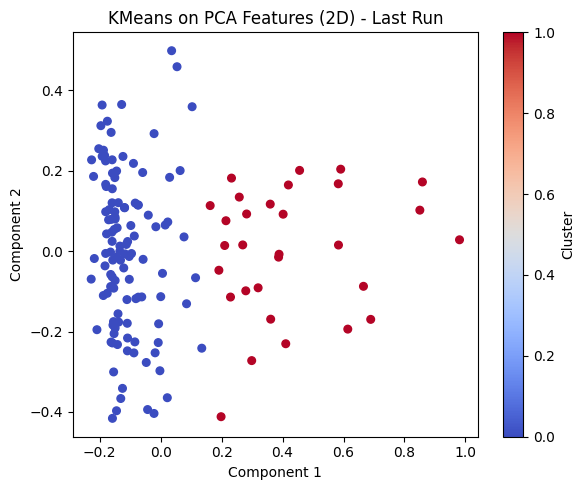

In [16]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)

# -------- PCA on INPUT FEATURES --------
pca = PCA(n_components=2)
Z   = pca.fit_transform(X)   # Z is now (N, 2)

num_runs = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
nmi_scores  = []

print("==== Running KMeans on PCA (2D) Features Across Multiple Runs ====\n")

for run in range(num_runs):
    print(f"--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)

    # -------- KMEANS ON 2D PCA FEATURES --------
    kmeans_pca = KMeans(n_clusters=2, random_state=run, max_iter=2000, n_init=10)
    kmeans_pca.fit(Z)

    probs_pca = kmeans_pca.transform(Z)
    probs_pca = probs_pca / probs_pca.sum(axis=1, keepdims=True)

    y_pred_pca = np.argmax(probs_pca, axis=1)

    # Fix label flip
    acc     = accuracy_score(y, y_pred_pca)
    acc_inv = accuracy_score(y, 1 - y_pred_pca)
    if acc_inv > acc:
        y_pred_pca          = 1 - y_pred_pca
        probs_pca[:, [0,1]] = probs_pca[:, [1,0]]
        acc                 = acc_inv

    prec = precision_score(y, y_pred_pca, zero_division=0)
    rec  = recall_score(y, y_pred_pca,    zero_division=0)
    f1   = f1_score(y, y_pred_pca,        zero_division=0)
    ll   = log_loss(y, probs_pca[:, 1])
    nmi  = normalized_mutual_info_score(y, y_pred_pca, average_method='arithmetic')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    log_losses.append(ll)
    nmi_scores.append(nmi)

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | LogLoss: {ll:.4f}")

print("\n================ FINAL SUMMARY (KMeans on PCA 2D) ================\n")
print(f"{'Metric':>15} | {'Mean':>10} \u00b1 {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  \u00b1 {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} \u00b1 {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  \u00b1 {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  \u00b1 {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  \u00b1 {np.std(nmi_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  \u00b1 {np.std(log_losses):.4f}")

# -------- PLOT (Displaying for the last run) --------
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_pred_pca, cmap='coolwarm', s=30)
plt.title("KMeans on PCA Features (2D) - Last Run")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()